In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


In [56]:
data=pd.read_csv("train.csv")
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


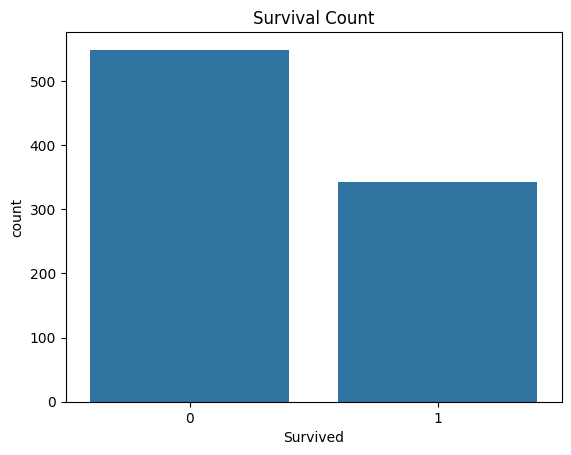

In [74]:
sns.countplot(x='Survived', data=data)
plt.title("Survival Count")
plt.show()

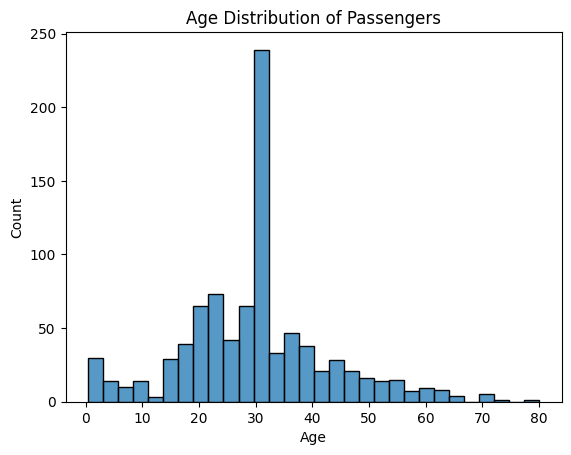

In [78]:
sns.histplot(data['Age'], bins=30)
plt.title("Age Distribution of Passengers")
plt.show()

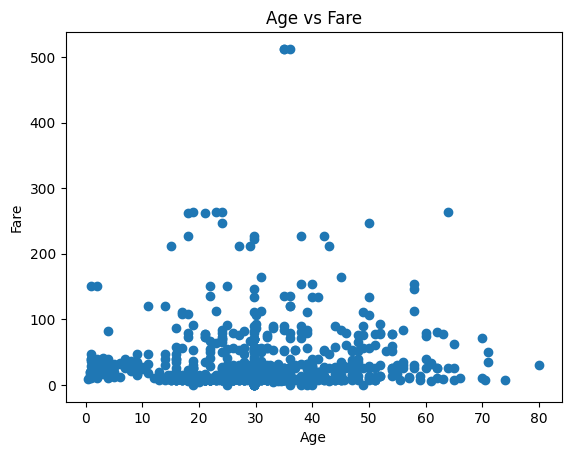

In [79]:
plt.scatter(data['Age'], data['Fare'])
plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

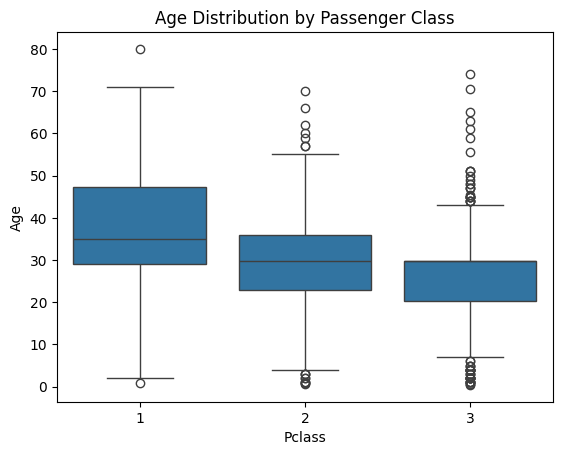

In [80]:
sns.boxplot(x='Pclass', y='Age', data=data)
plt.title("Age Distribution by Passenger Class")
plt.show()

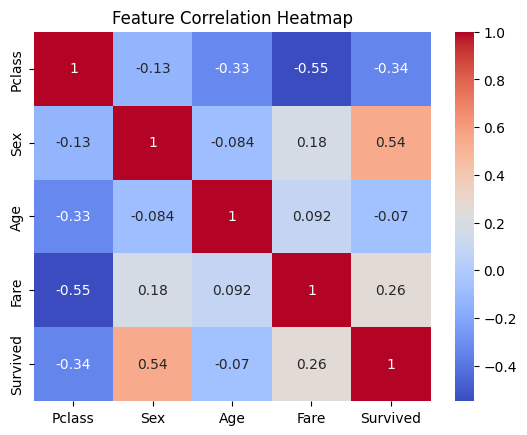

In [81]:
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [57]:
data=data[['Pclass','Sex','Age','Fare','Survived']]

In [58]:
data['Sex']=data['Sex'].map({ 'male' : 0, 'female' : 1 })

In [59]:
data['Age'] = data['Age'].fillna(data['Age'].mean())

In [60]:
x = data[['Pclass','Sex','Age','Fare']]
y = data['Survived']

In [61]:
x_train , x_test , y_train , y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [62]:
model = LogisticRegression()

In [63]:
model.fit(x_train, y_train)

/Users/sania/Desktop/webapp/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/sania/Desktop/webapp/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/sania/Desktop/webapp/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept


LogisticRegression()

In [70]:
y_hat = model.predict(x_test)

In [71]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Confusion Matrix:\n", cm)

Accuracy: 0.7988826815642458
Precision: 0.7714285714285715
Recall: 0.7297297297297297
F1 Score: 0.75
Confusion Matrix:
 [[89 16]
 [20 54]]


In [1]:
import pickle

pickle.dump(model, open("models/titanic_model.pkl", "wb"))

NameError: name 'model' is not defined